In [ ]:
using Graphs
using Random
using Statistics
using Plots

In [2]:

# Erdős–Rényi graph with average degree k
function generate_ER(N, k)
    p = k / (N - 1)
    return erdos_renyi(N, p)
end

# Barabási–Albert graph with average degree ~2m
function generate_BA(N, k)
    m = Int(round(k / 2))
    return barabasi_albert(N, m)
end

generate_BA (generic function with 1 method)

In [3]:
function SIS_simulation(g, β, μ; 
    Tmax=1000, Ttrans=900, ρ0=0.2)

    N = nv(g)

    # Initial state: 1 = infected, 0 = susceptible
    state = rand(N) .< ρ0
    state = Int.(state)

    ρ_t = zeros(Float64, Tmax)

    for t in 1:Tmax
        new_state = copy(state)

        # --- Recovery step ---
        for i in 1:N
            if state[i] == 1
                if rand() < μ
                    new_state[i] = 0
                end
            end
        end

        # --- Infection step ---
        for i in 1:N
            if state[i] == 0  # susceptible
                for j in neighbors(g, i)
                    if state[j] == 1
                        if rand() < β
                            new_state[i] = 1
                            break
                        end
                    end
                end
            end
        end

        state = new_state
        ρ_t[t] = sum(state) / N
    end

    # Return stationary average
    return mean(ρ_t[Ttrans:end])
end

SIS_simulation (generic function with 1 method)

In [4]:
function compute_rho(g, β, μ; Nrep=50)
    values = zeros(Nrep)
    
    for r in 1:Nrep
        values[r] = SIS_simulation(g, β, μ)
    end
    
    return mean(values)
end

compute_rho (generic function with 1 method)

In [20]:
function MMCA_simulation(g, β, μ; 
    Tmax=1000, tol=1e-6)

    N = nv(g)

    # Initial probabilities (same idea as ρ0 = 0.2)
    p = fill(0.2, N)
    p_new = similar(p)

    for t in 1:Tmax
        for i in 1:N
            prod_term = 1.0

            # product over neighbors
            for j in neighbors(g, i)
                prod_term *= (1 - β * p[j])
            end

            infection_prob = 1 - prod_term

            p_new[i] = (1 - p[i]) * infection_prob + (1 - μ) * p[i]
        end

        # convergence check
        if maximum(abs.(p_new .- p)) < tol
            # println("Converged at t=$t")
            break
        end

        p .= p_new
    end

    # average infection probability = ρ
    return mean(p)
end

MMCA_simulation (generic function with 1 method)

In [21]:
function compute_MMCA_curve(g, β_values, μ)
    ρ_vals = Float64[]

    for β in β_values
        ρ = MMCA_simulation(g, β, μ)
        push!(ρ_vals, ρ)
    end

    return ρ_vals
end

compute_MMCA_curve (generic function with 1 method)

In [36]:
function QMF_simulation(g, β, μ; Tmax=1000, tol=1e-6)
    N = nv(g)

    # initial probabilities
    p = fill(0.2, N)
    p_new = similar(p)

    for t in 1:Tmax
        for i in 1:N
            # sum over neighbors
            s = 0.0
            for j in neighbors(g, i)
                s += p[j]
            end

            p_new[i] = (β * s) / (μ + β * s + 1e-12)  # avoid division by zero
        end

        # convergence check
        if maximum(abs.(p_new .- p)) < tol
            break
        end

        p .= p_new
    end

    return mean(p)  # ρ
end

QMF_simulation (generic function with 1 method)

In [ ]:
function compute_QMF_curve(g, β_values, μ)
    ρ_vals = Float64[]

    for β in β_values
        ρ = QMF_simulation(g, β, μ)
        push!(ρ_vals, ρ)
    end

    return ρ_vals
end

compute_QMF_curve (generic function with 1 method)

In [ ]:
function run_experiment_full()
    N = 1000
    β_values = 0.0:0.01:1
    μ_values = [0.2, 0.4]

    networks = Dict(
        "ER_k4" => generate_ER(N, 4),
        "ER_k6" => generate_ER(N, 6),
        "BA_k4" => generate_BA(N, 4),
        "BA_k6" => generate_BA(N, 6)
    )

    results_MC = Dict()
    results_MMCA = Dict()
    results_QMF = Dict()

    for μ in μ_values
        println("Running μ = $μ")

        for (name, g) in networks
            println("  Network: $name")

            # MC
            ρ_mc = [compute_rho(g, β, μ) for β in β_values]

            # MMCA
            ρ_mmca = compute_MMCA_curve(g, β_values, μ)

            # QMF
            println("    Running QMF...")
            ρ_qmf = compute_QMF_curve(g, β_values, μ)

            results_MC[(name, μ)] = ρ_mc
            results_MMCA[(name, μ)] = ρ_mmca 
            results_QMF[(name, μ)] = ρ_qmf
        end
        
    end

    return β_values, results_MC, results_MMCA, results_QMF
end

run_experiment_full (generic function with 1 method)

In [49]:
function plot_full_comparison_by_mu(β_values, results_MC, results_MMCA, results_QMF)
    # Sort μ values (so plots appear in order)
    μ_values = sort(unique(k[2] for k in keys(results_MC)))

    # Fixed order of networks for consistency
    network_order = ["ER_k4", "ER_k6", "BA_k4", "BA_k6"]

    for μ in μ_values
        p = plot(
            title = "SIS Epidemic Spreading (μ = $μ)",
            legend = :topleft,
            lw = 2
        )

        for name in network_order
            key = (name, μ)

            if haskey(results_MC, key) &&
               haskey(results_MMCA, key) &&
               haskey(results_QMF, key)

                ρ_mc   = results_MC[key]
                ρ_mmca = results_MMCA[key]
                ρ_qmf  = results_QMF[key]

                # --- Monte Carlo (solid) ---
                plot!(p, β_values, ρ_mc,
                      label = "$name (MC)")

                # --- MMCA (dashed) ---
                plot!(p, β_values, ρ_mmca,
                      linestyle = :dash,
                      label = "$name (MMCA)")

                # --- QMF (dotted) ---
                plot!(p, β_values, ρ_qmf,
                      linestyle = :dot,
                      label = "$name (QMF)")
            end
        end

        xlabel!(p, "β (infection probability)")
        ylabel!(p, "ρ (infected fraction)")

        display(p)
    end
end

plot_full_comparison_by_mu (generic function with 1 method)

In [41]:
β_values, results_MC, results_MMCA, results_QMF = run_experiment_full()

Running μ = 0.2
  Network: BA_k6
    Running QMF...
  Network: BA_k4
    Running QMF...
  Network: ER_k6
    Running QMF...
  Network: ER_k4
    Running QMF...
Running μ = 0.4
  Network: BA_k6
    Running QMF...
  Network: BA_k4
    Running QMF...
  Network: ER_k6
    Running QMF...
  Network: ER_k4
    Running QMF...


(0.0:0.01:1.0, Dict{Any, Any}(("ER_k6", 0.2) => [0.0, 0.0, 0.0, 0.0, 0.1637750495049505, 0.29967821782178217, 0.39357861386138615, 0.4611799999999999, 0.5129673267326732, 0.5561847524752476  …  0.8320796039603959, 0.8321786138613859, 0.8323942574257426, 0.8321817821782179, 0.832428910891089, 0.8325136633663365, 0.8325968316831682, 0.8325405940594058, 0.8328518811881187, 0.8328348514851485], ("BA_k6", 0.4) => [0.0, 0.0, 0.0, 0.0, 0.0, 0.08749861386138612, 0.1378738613861386, 0.18658059405940597, 0.23044257425742573, 0.26957603960396037  …  0.7103013861386138, 0.7099942574257426, 0.7104912871287128, 0.7109225742574258, 0.7107760396039603, 0.7113663366336632, 0.7114360396039604, 0.7117958415841583, 0.7118005940594057, 0.7120706930693068], ("BA_k4", 0.2) => [0.0, 0.0, 0.0, 0.0058980198019801975, 0.1069560396039604, 0.17212217821782175, 0.2386045544554455, 0.2942142574257426, 0.343660198019802, 0.3874613861386139  …  0.8289140594059405, 0.8292877227722772, 0.829460396039604, 0.8295308910891

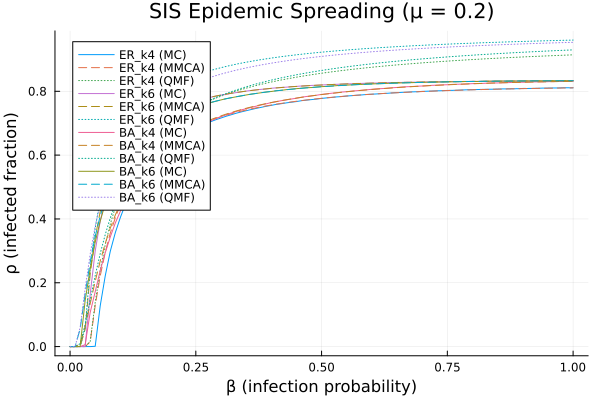

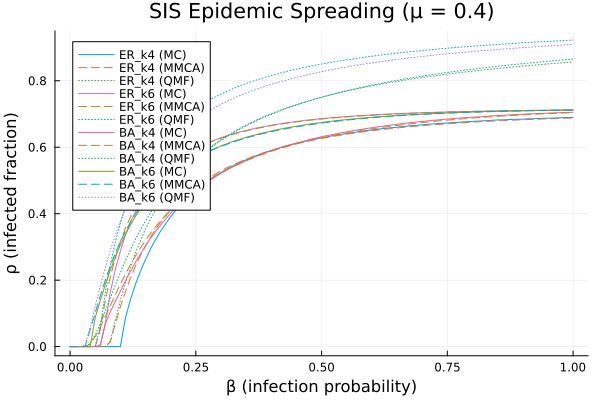

In [42]:
plot_full_comparison_by_mu(β_values, results_MC, results_MMCA, results_QMF)

In [47]:
function plot_full_comparison_by_mu_and_algorithm(β_values, results_MC, results_MMCA, results_QMF)

    μ_values = sort(unique(k[2] for k in keys(results_MC)))

    network_order = ["ER_k4", "ER_k6", "BA_k4", "BA_k6"]

    for μ in μ_values

        # =========================
        # 1. Monte Carlo plot
        # =========================
        p_mc = plot(
            title = "SIS Monte Carlo (μ = $μ)",
            legend = :topleft,
            lw = 2
        )

        for name in network_order
            key = (name, μ)

            if haskey(results_MC, key)
                ρ_mc = results_MC[key]

                plot!(p_mc, β_values, ρ_mc,
                      label = name, marker=:circle, markersize=3)
            end
        end

        xlabel!(p_mc, "β (infection probability)")
        ylabel!(p_mc, "ρ (infected fraction)")
        display(p_mc)

        # =========================
        # 2. MMCA plot
        # =========================
        p_mmca = plot(
            title = "SIS MMCA (μ = $μ)",
            legend = :topleft,
            lw = 2,
            linestyle = :dash
        )

        for name in network_order
            key = (name, μ)

            if haskey(results_MMCA, key)
                ρ_mmca = results_MMCA[key]

                plot!(p_mmca, β_values, ρ_mmca,
                      label = name, marker=:circle, markersize=3)
            end
        end

        xlabel!(p_mmca, "β (infection probability)")
        ylabel!(p_mmca, "ρ (infected fraction)")
        display(p_mmca)

        # =========================
        # 3. QMF plot
        # =========================
        p_qmf = plot(
            title = "SIS QMF (μ = $μ)",
            legend = :topleft,
            lw = 2,
            linestyle = :dot
        )

        for name in network_order
            key = (name, μ)

            if haskey(results_QMF, key)
                ρ_qmf = results_QMF[key]

                plot!(p_qmf, β_values, ρ_qmf,
                      label = name, marker=:circle, markersize=3)
            end
        end

        xlabel!(p_qmf, "β (infection probability)")
        ylabel!(p_qmf, "ρ (infected fraction)")
        display(p_qmf)

    end
end

plot_full_comparison_by_mu_and_algorithm (generic function with 1 method)

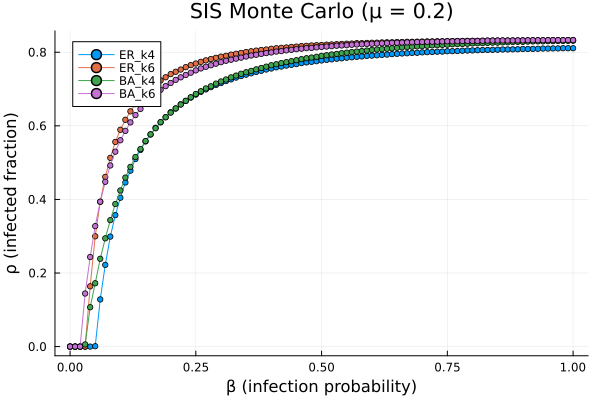

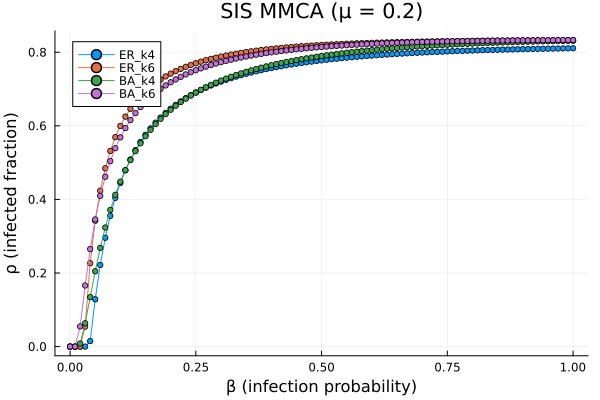

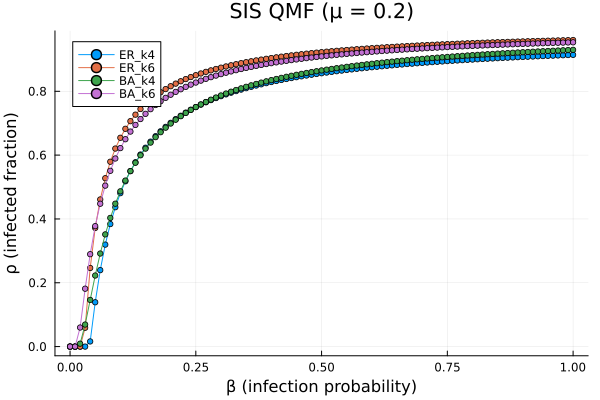

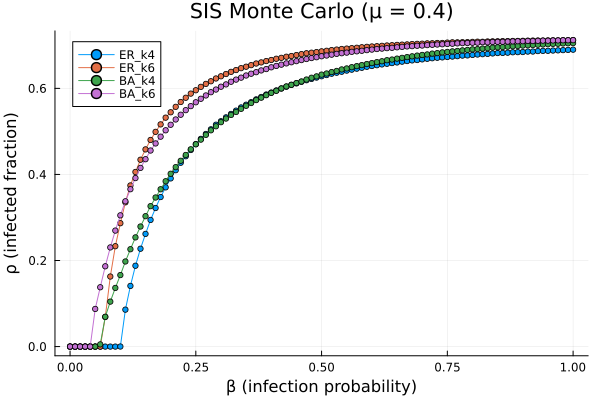

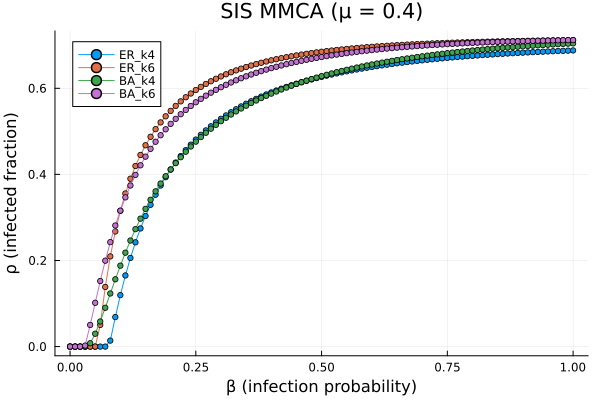

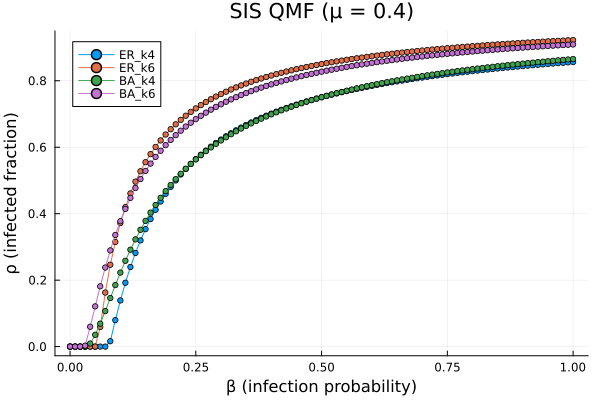

In [48]:
plot_full_comparison_by_mu_and_algorithm(β_values, results_MC, results_MMCA, results_QMF)

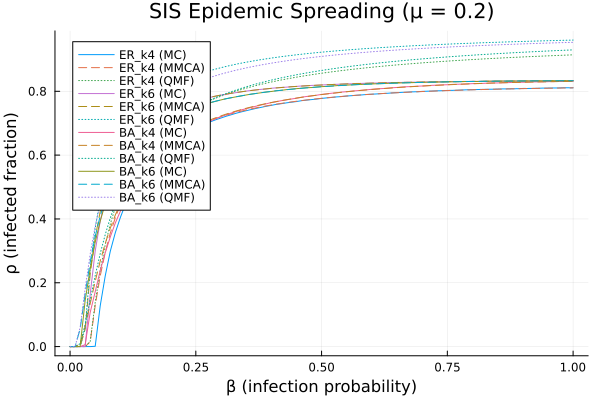

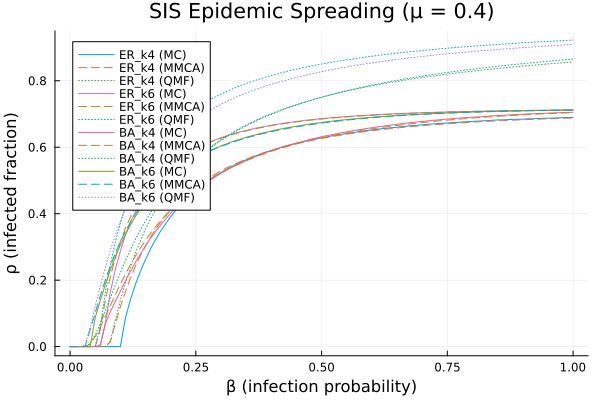

In [50]:
plot_full_comparison_by_mu(β_values, results_MC, results_MMCA, results_QMF)